# 05 — YOLO on native-resolution tiles

Notebooks 03 and 04 ended with two detectors that don't work: the sliding-window CNN finds Waldo but buries him
in thousands of false boxes, and YOLO on the whole scene is quiet but misses most Waldos. This notebook attacks the
most likely root cause of YOLO's misses.

**The problem: Waldo was too small to see.** The Roboflow export used in notebooks 03–04 stretched every scene to
640×640. The scans are 1,300–2,800 px wide, so Waldo — about 50×60 px natively (median) — was squeezed to roughly
18×35 px, and the smallest ones to 10×20 px. YOLO11n's coarsest feature stride is 32 px; an object that size is
about one cell of its coarsest map.

**The fix: don't downscale — tile.** We go back to the native scans (Hey-Waldo `original-images/`) and show YOLO
native-scale 640×640 *tiles* instead of a whole shrunken scene:

* **Training tiles** come from a fold's training scenes only: tiles placed around each real Waldo at random offsets,
  background-only tiles (which carry the hard negatives: other striped shirts, glasses, faces), and background tiles
  with a real, native-resolution Waldo crop from a *different* training scene pasted in.
* **Inference** covers the whole scene with an overlapping tile grid (overlap ≥ the largest Waldo, so every Waldo is
  fully inside some tile), runs YOLO per tile, maps boxes back to scene coordinates and merges duplicates with our
  hand-written NMS from notebook 03.

**A data bug found along the way — and why these numbers can be trusted.** The first version of this notebook
mapped Roboflow's boxes onto the native scans by rescaling alone. For 8 of the 19 scenes Roboflow's export had
flipped or rotated the page (notebook 02, Part 2), so that version trained on wrong labels and was scored against
wrong ground truth: Waldo was in its top-10 boxes for only 4 of 18 scenes. After the orientation-aware fix in
notebook 02, the identical training recipe puts him in the top-10 for 10 of 18. So most of the gain in this notebook
comes from correct labels, not from a cleverer model.

**Evaluation protocol — stricter than notebook 04, on purpose.**
* Same scene-level 5-fold split, same `match_detections` at IoU ≥ 0.3, same 21 boxes — directly comparable.
* No held-out scene is touched during training: ultralytics needs a validation set, so we hand it a few *training*
  tiles, train a fixed number of epochs and use the last epoch. (Notebook 04 let held-out scenes pick the checkpoint
  and stop training, which is mildly optimistic.)
* The confidence threshold is chosen without peeking: for each fold we pick the threshold that maximises F1 on the
  *other four* folds' detections, then apply it to the held-out fold ("leave-one-fold-out").
* Because a puzzle usually has exactly one Waldo, we also report **hit@k**: is Waldo among the detector's top-k
  most confident boxes for the scene? That is the metric matching how the demo is used.

In [1]:
import ast
import json
import shutil
import sys
import time
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from PIL import Image
from ultralytics import YOLO

from src.data.tiling import (
    DEFAULT_SCALES,
    OVERLAP,
    TILE,
    build_native_crop_pool,
    export_tiled_train,
    predict_multiscale,
    tile_grid,
)
from src.eval.metrics import match_detections, mean_localization_error, precision_recall

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RUNS_DIR = PROJECT_ROOT / "runs"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
plt.rcParams["figure.dpi"] = 110

YOLO_DEVICE = 0 if torch.cuda.is_available() else "cpu"
YOLO_BATCH = 16 if torch.cuda.is_available() else 8
EPOCHS = 25
IOU_THRESHOLD = 0.3
OOF_CONF = 0.05  # collect held-out detections down to this confidence, then choose the operating point afterwards
print(f"YOLO device: {YOLO_DEVICE}, batch size: {YOLO_BATCH}, epochs: {EPOCHS}")

scenes = pd.read_csv(PROCESSED_DIR / "native_manifest.csv")
scenes["boxes"] = scenes["boxes"].apply(ast.literal_eval)
scenes["scene_id"] = scenes["scene_id"].astype(str)
fold_assignment = pd.read_csv(PROCESSED_DIR / "fold_assignment.csv")
fold_assignment["scene_id"] = fold_assignment["scene_id"].astype(str)
N_FOLDS = fold_assignment["val_fold"].nunique()
scenes_folds = scenes.merge(fold_assignment, on="scene_id")

YOLO device: cpu, batch size: 8, epochs: 25


## How small was Waldo, really?

Native box sizes next to what they became after the 640×640 stretch, and how many tiles a scene needs.

In [2]:
rows = []
for _, s in scenes.iterrows():
    for (x1, y1, x2, y2) in s["boxes"]:
        rows.append({
            "scene_id": s["scene_id"], "scene": f"{s['width']}x{s['height']}",
            "native_w": x2 - x1, "native_h": y2 - y1,
            "stretched_w": round((x2 - x1) * 640 / s["width"], 1), "stretched_h": round((y2 - y1) * 640 / s["height"], 1),
            "tiles": len(tile_grid(s["width"], s["height"])),
        })
sizes = pd.DataFrame(rows)
print(sizes[["native_w", "native_h", "stretched_w", "stretched_h", "tiles"]].describe().loc[["min", "50%", "max"]].round(1))
print(f"\nLargest Waldo box: {sizes['native_w'].max()} px wide (tile overlap is {OVERLAP} px)")

     native_w  native_h  stretched_w  stretched_h  tiles
min      25.0      33.0         10.0         20.0    6.0
50%      48.0      61.0         17.8         34.9   12.0
max     140.0     195.0         41.1         71.2   28.0

Largest Waldo box: 140 px wide (tile overlap is 240 px)


## What the training tiles look like

One real-Waldo tile, one background-only tile and one synthetic (pasted) tile from fold 0's training scenes.
Green boxes are the training labels. This also builds the native-resolution Waldo crop pool that the synthetic
tiles paste from (notebook 02 had to shrink its crops to the stretched 640-space; these are full quality).

demo tile counts: {'positive': 34, 'negative': 15, 'synthetic': 15}


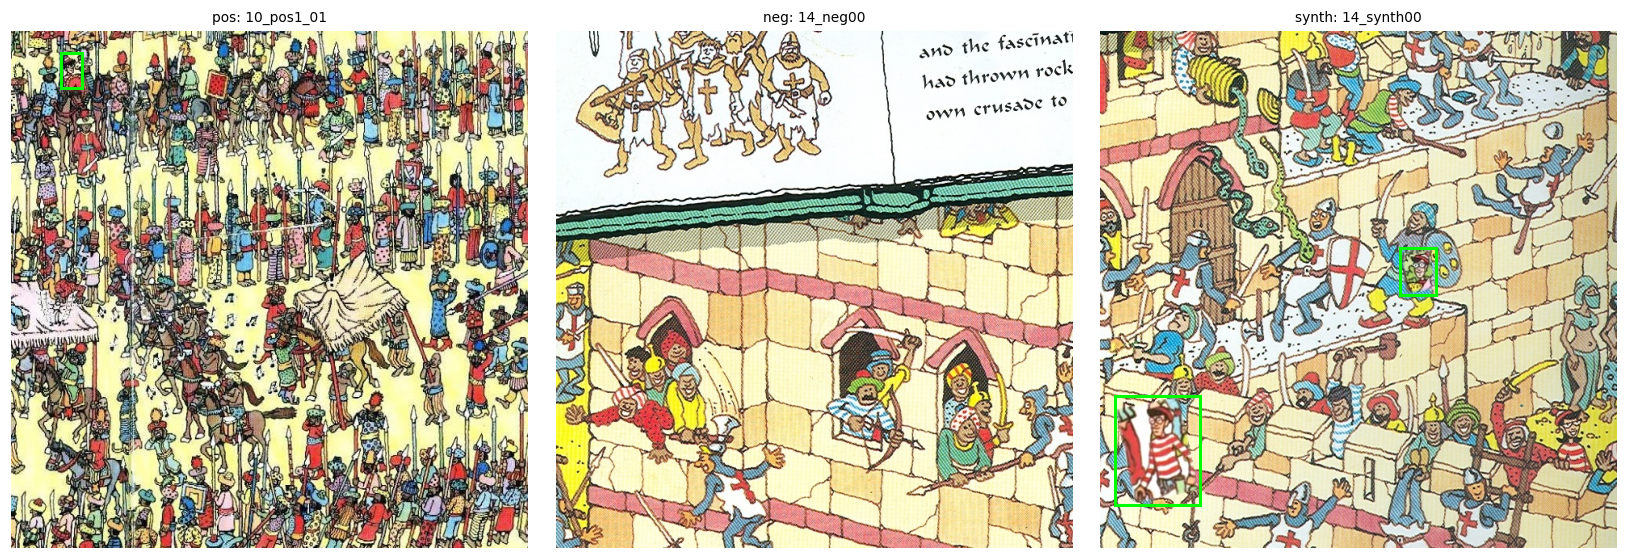

In [3]:
native_crop_pool = build_native_crop_pool(scenes, PROCESSED_DIR / "crop_pool_native")

demo_dir = PROCESSED_DIR / "tiled_demo"
counts = export_tiled_train(
    scenes_folds.query("val_fold != 0"), native_crop_pool, demo_dir,
    n_pos_per_box=2, n_neg_per_scene=1, n_synth_per_scene=1, seed=123,
)
print("demo tile counts:", counts)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, kind in zip(axes, ["pos", "neg", "synth"]):
    path = sorted((demo_dir / "train" / "images").glob(f"*_{kind}*.jpg"))[3]
    ax.imshow(Image.open(path))
    label_path = demo_dir / "train" / "labels" / f"{path.stem}.txt"
    for line in label_path.read_text().splitlines():
        _, cx, cy, w, h = map(float, line.split())
        ax.add_patch(plt.Rectangle(((cx - w / 2) * TILE, (cy - h / 2) * TILE), w * TILE, h * TILE, fill=False, edgecolor="lime", linewidth=2))
    ax.set_title(f"{kind}: {path.stem}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()
shutil.rmtree(demo_dir)

## Train five fold models and one final model

Per fold: pretrained `yolo11n.pt` fine-tuned for 25 epochs on ~250 tiles built from that fold's 15 training scenes
(`imgsz=640`, batch 8, ultralytics' default augmentation). Then one **final model** on all 19 scenes with the identical
recipe — that's the one the demo app uses, and the five fold models are what tell us how well it should do on a new
scene. (Notebook 04's demo model was just the best-looking fold, which is trained on 15 scenes and picked using its own
held-out scenes.)

Resumable: a run is skipped if its `done.txt` marker exists, so an interrupted overnight run continues where it
stopped. Tile sets are regenerated deterministically from the seed and deleted after training to keep the disk tidy.

In [4]:
def train_tiled(train_scenes, run_name, seed):
    run_dir = RUNS_DIR / run_name
    weights = run_dir / "weights" / "last.pt"
    if (run_dir / "done.txt").exists():
        print(f"{run_name}: reusing finished run")
        return weights

    data_dir = PROCESSED_DIR / run_name
    counts = export_tiled_train(
        train_scenes, native_crop_pool, data_dir, n_pos_per_box=8, n_neg_per_scene=4, n_synth_per_scene=5, seed=seed
    )
    print(f"{run_name}: {len(train_scenes)} scenes -> tiles {counts}")
    start = time.perf_counter()
    YOLO("yolo11n.pt").train(
        data=str(data_dir / "data.yaml"), epochs=EPOCHS, imgsz=TILE, batch=YOLO_BATCH, device=YOLO_DEVICE,
        val=False, project=str(RUNS_DIR), name=run_name, exist_ok=True, verbose=False, plots=False,
    )
    (run_dir / "done.txt").write_text(f"trained in {time.perf_counter() - start:.0f}s")
    shutil.rmtree(data_dir)
    print(f"{run_name}: trained in {(time.perf_counter() - start) / 60:.0f} min")
    return weights


fold_weights = {}
for fold in range(N_FOLDS):
    fold_weights[fold] = train_tiled(scenes_folds.query("val_fold != @fold"), f"tiled_fold{fold}", seed=fold)
final_weights = train_tiled(scenes, "tiled_final", seed=100)

tiled_fold0: reusing finished run
tiled_fold1: reusing finished run
tiled_fold2: reusing finished run
tiled_fold3: reusing finished run
tiled_fold4: reusing finished run
tiled_final: reusing finished run


## Held-out detections, two ways of scanning

Each fold model scans the whole native-resolution scenes of *its own* held-out fold, so everything below —
thresholds, precision/recall, hit@k — comes from out-of-fold detections, never from a scene the scoring model
trained on. We scan in two ways:

* **single-scale**: the native-resolution tile grid described above (`conf ≥ 0.05`);
* **multi-scale**: the same model also scans a 0.75× and a 1.5× copy of the scene, boxes are mapped back and merged
  with NMS (`conf ≥ 0.01`). Waldo's native size varies ~5× across scans (25–140 px wide) while training sees him
  mostly at one scale, so this lets the model meet him at a size it knows, at ~3× the compute.

**Disclosure:** the scale set (0.75, 1, 1.5) was picked from four variants I tried on these same 19 held-out scenes
(1+1.5, 0.75+1+1.5 and 1+1.5+2 were the others), so the multi-scale numbers are somewhat optimistic; single-scale is
the untuned reference.

In [5]:
SETTINGS = {
    "single-scale": dict(scales=(1.0,), conf=0.05),
    "multi-scale": dict(scales=DEFAULT_SCALES, conf=0.01),
}
det_dfs, infer_seconds = {}, {}
for label, cfg in SETTINGS.items():
    rows, seconds = [], []
    for fold in range(N_FOLDS):
        model = YOLO(str(fold_weights[fold]))
        for _, scene in scenes_folds.query("val_fold == @fold").iterrows():
            image = Image.open(scene["image_path"])
            start = time.perf_counter()
            detections = predict_multiscale(model, image, scales=cfg["scales"], conf=cfg["conf"], device=YOLO_DEVICE)
            seconds.append(time.perf_counter() - start)
            for (x1, y1, x2, y2), score in detections:
                rows.append({"scene_id": scene["scene_id"], "fold": fold, "x1": x1, "y1": y1, "x2": x2, "y2": y2, "score": score})
    df = pd.DataFrame(rows).sort_values(["scene_id", "score"], ascending=[True, False]).reset_index(drop=True)
    tag = label.replace("-", "_")
    df.to_csv(PROCESSED_DIR / f"tiled_oof_detections_{tag}.csv", index=False)
    det_dfs[label], infer_seconds[label] = df, float(np.mean(seconds))
    print(f"{label}: {len(df)} held-out detections across {df['scene_id'].nunique()} scenes, "
          f"{infer_seconds[label]:.1f} s per full scene (CPU)")

single-scale: 78 held-out detections across 17 scenes, 1.6 s per full scene (CPU)


multi-scale: 1132 held-out detections across 19 scenes, 5.5 s per full scene (CPU)


## Precision / recall across thresholds

Pooled over all 19 held-out scenes. This table is for *understanding* the trade-off; the honest headline number is the
leave-one-fold-out one further down, because picking the best row of this table and reporting it would be choosing the
threshold on the same data we score it on.

In [6]:
def match_scene(det_df, scene, threshold):
    d = det_df[(det_df["scene_id"] == scene["scene_id"]) & (det_df["score"] >= threshold)]
    preds = [tuple(r) for r in d[["x1", "y1", "x2", "y2"]].values]  # already sorted by descending score
    return match_detections(preds, scene["boxes"], iou_threshold=IOU_THRESHOLD)


def f1(p, r):
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0


THRESHOLDS = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
sweep_dfs = {}
for label, det_df in det_dfs.items():
    sweep_rows = []
    for t in THRESHOLDS:
        matches = [match_scene(det_df, s, t) for _, s in scenes_folds.iterrows()]
        p, r = precision_recall(matches)
        sweep_rows.append({
            "threshold": t, "tp": sum(m.true_positives for m in matches), "fp": sum(m.false_positives for m in matches),
            "fn": sum(m.false_negatives for m in matches), "precision": round(p, 3), "recall": round(r, 3), "f1": round(f1(p, r), 3),
        })
    sweep_dfs[label] = pd.DataFrame(sweep_rows)
    sweep_dfs[label].to_csv(PROCESSED_DIR / f"tiled_threshold_sweep_{label.replace('-', '_')}.csv", index=False)
    print(f"--- {label}")
    display(sweep_dfs[label])

--- single-scale


,threshold,tp,fp,fn,precision,recall,f1
0,0.05,11,67,10,0.141,0.524,0.222
1,0.10,10,36,11,0.217,0.476,0.299
2,0.15,9,26,12,0.257,0.429,0.321
3,0.20,8,20,13,0.286,0.381,0.327
4,0.25,8,10,13,0.444,0.381,0.410
5,0.30,8,8,13,0.500,0.381,0.432
6,0.40,7,5,14,0.583,0.333,0.424
7,0.50,7,2,14,0.778,0.333,0.467
8,0.60,7,0,14,1.000,0.333,0.500
9,0.70,6,0,15,1.000,0.286,0.444


--- multi-scale


,threshold,tp,fp,fn,precision,recall,f1
0,0.05,15,240,6,0.059,0.714,0.109
1,0.10,15,130,6,0.103,0.714,0.181
2,0.15,13,85,8,0.133,0.619,0.218
3,0.20,12,60,9,0.167,0.571,0.258
4,0.25,12,35,9,0.255,0.571,0.353
5,0.30,12,24,9,0.333,0.571,0.421
6,0.40,11,18,10,0.379,0.524,0.440
7,0.50,8,8,13,0.500,0.381,0.432
8,0.60,8,3,13,0.727,0.381,0.500
9,0.70,7,0,14,1.000,0.333,0.500


## Headline result: leave-one-fold-out threshold

For each fold, choose the threshold maximising F1 on the other four folds, and apply it to the held-out fold. (Ties go
to the higher threshold — fewer false alarms.) This is the closest thing to "what would happen on scenes the model and
its threshold have never seen".

In [7]:
def pooled_f1(det_df, threshold, scene_rows):
    p, r = precision_recall([match_scene(det_df, s, threshold) for _, s in scene_rows.iterrows()])
    return f1(p, r)


lofo_results = {}
for label, det_df in det_dfs.items():
    matches, thresholds, per_scene = [], {}, []
    for fold in range(N_FOLDS):
        others = scenes_folds.query("val_fold != @fold")
        best_t = max(THRESHOLDS, key=lambda t: (round(pooled_f1(det_df, t, others), 6), t))
        thresholds[fold] = best_t
        for _, scene in scenes_folds.query("val_fold == @fold").iterrows():
            m = match_scene(det_df, scene, best_t)
            matches.append(m)
            per_scene.append({"scene_id": scene["scene_id"], "fold": fold, "threshold": best_t,
                              "tp": m.true_positives, "fp": m.false_positives, "fn": m.false_negatives})
    p, r = precision_recall(matches)
    mle = mean_localization_error(matches)
    tp, fp, fn = (sum(getattr(m, k) for m in matches) for k in ("true_positives", "false_positives", "false_negatives"))
    lofo_results[label] = pd.DataFrame(per_scene)
    lofo_results[label].to_csv(PROCESSED_DIR / f"tiled_cv_results_{label.replace('-', '_')}.csv", index=False)
    print(f"{label}: per-fold thresholds {thresholds}")
    print(f"  TP {tp}, FP {fp}, FN {fn}   precision {p:.3f}   recall {r:.3f}   F1 {f1(p, r):.3f}"
          + (f"   mean localization error {mle:.1f}px" if mle else ""))

# the file notebook 06 reads for the comparison table: the multi-scale results
lofo_results["multi-scale"].to_csv(PROCESSED_DIR / "tiled_cv_results.csv", index=False)

single-scale: per-fold thresholds {0: 0.7, 1: 0.6, 2: 0.6, 3: 0.6, 4: 0.6}
  TP 6, FP 0, FN 15   precision 1.000   recall 0.286   F1 0.444   mean localization error 6.2px


multi-scale: per-fold thresholds {0: 0.7, 1: 0.7, 2: 0.6, 3: 0.6, 4: 0.3}
  TP 7, FP 14, FN 14   precision 0.333   recall 0.333   F1 0.333   mean localization error 7.0px


## "Is Waldo in the top-k?"

Where's Waldo has one Waldo per page, so a useful tool doesn't need a perfect threshold — it needs to *rank* the right
box highly. A scene counts as a hit@k if any of its k highest-confidence boxes matches a real Waldo (IoU ≥ 0.3).
Threshold-free, so it also shows how much is lost by thresholding at all. (Scene 11 has no annotated Waldo and is
excluded, leaving 18 scenes.)

In [8]:
def rank_of_first_correct(det_df, scene):
    d = det_df[det_df["scene_id"] == scene["scene_id"]]
    for i in range(len(d)):
        box = tuple(d.iloc[i][["x1", "y1", "x2", "y2"]].values)
        if match_detections([box], scene["boxes"], iou_threshold=IOU_THRESHOLD).true_positives:
            return i + 1
    return None


with_waldo = scenes_folds[scenes_folds["boxes"].apply(len) > 0]
rank_tables, hitk_rows = {}, []
for label, det_df in det_dfs.items():
    ranks = pd.DataFrame(
        [{"scene_id": s["scene_id"], "fold": s["val_fold"], "rank_of_first_correct_box": rank_of_first_correct(det_df, s)}
         for _, s in with_waldo.iterrows()]
    )
    rank_tables[label] = ranks
    for k in [1, 3, 5, 10, 20]:
        hits = int((ranks["rank_of_first_correct_box"] <= k).sum())
        hitk_rows.append({"scanning": label, "k": k, "scenes_hit": hits, "of": len(ranks), "hit_rate": round(hits / len(ranks), 2)})
hitk_df = pd.DataFrame(hitk_rows)
hitk_df.to_csv(PROCESSED_DIR / "tiled_hit_at_k.csv", index=False)
hitk_df.pivot(index="k", columns="scanning", values="scenes_hit").assign(of=len(with_waldo))

scanning,multi-scale,single-scale,of
k,,,
1,10,8,18
3,13,10,18
5,13,10,18
10,14,10,18
20,14,10,18


In [9]:
per_scene_ranks = rank_tables["single-scale"].merge(
    rank_tables["multi-scale"], on=["scene_id", "fold"], suffixes=("_single", "_multi")
).sort_values("rank_of_first_correct_box_multi", na_position="last")
print("rank of the first correct box per scene (NaN = never among the detections):")
per_scene_ranks

rank of the first correct box per scene (NaN = never among the detections):


,scene_id,fold,rank_of_first_correct_box_single,rank_of_first_correct_box_multi
0,1,0,NaN,1.0
4,5,3,1.0,1.0
5,6,0,NaN,1.0
7,8,3,1.0,1.0
9,10,2,1.0,1.0
14,16,2,1.0,1.0
12,14,1,3.0,1.0
10,12,0,1.0,1.0
16,18,2,1.0,1.0
15,17,1,1.0,1.0


## What it looks like on held-out scenes

Multi-scale detections from each scene's own held-out fold model. Green = ground truth, red = the three most
confident boxes (with score). Scenes are downscaled only for display.

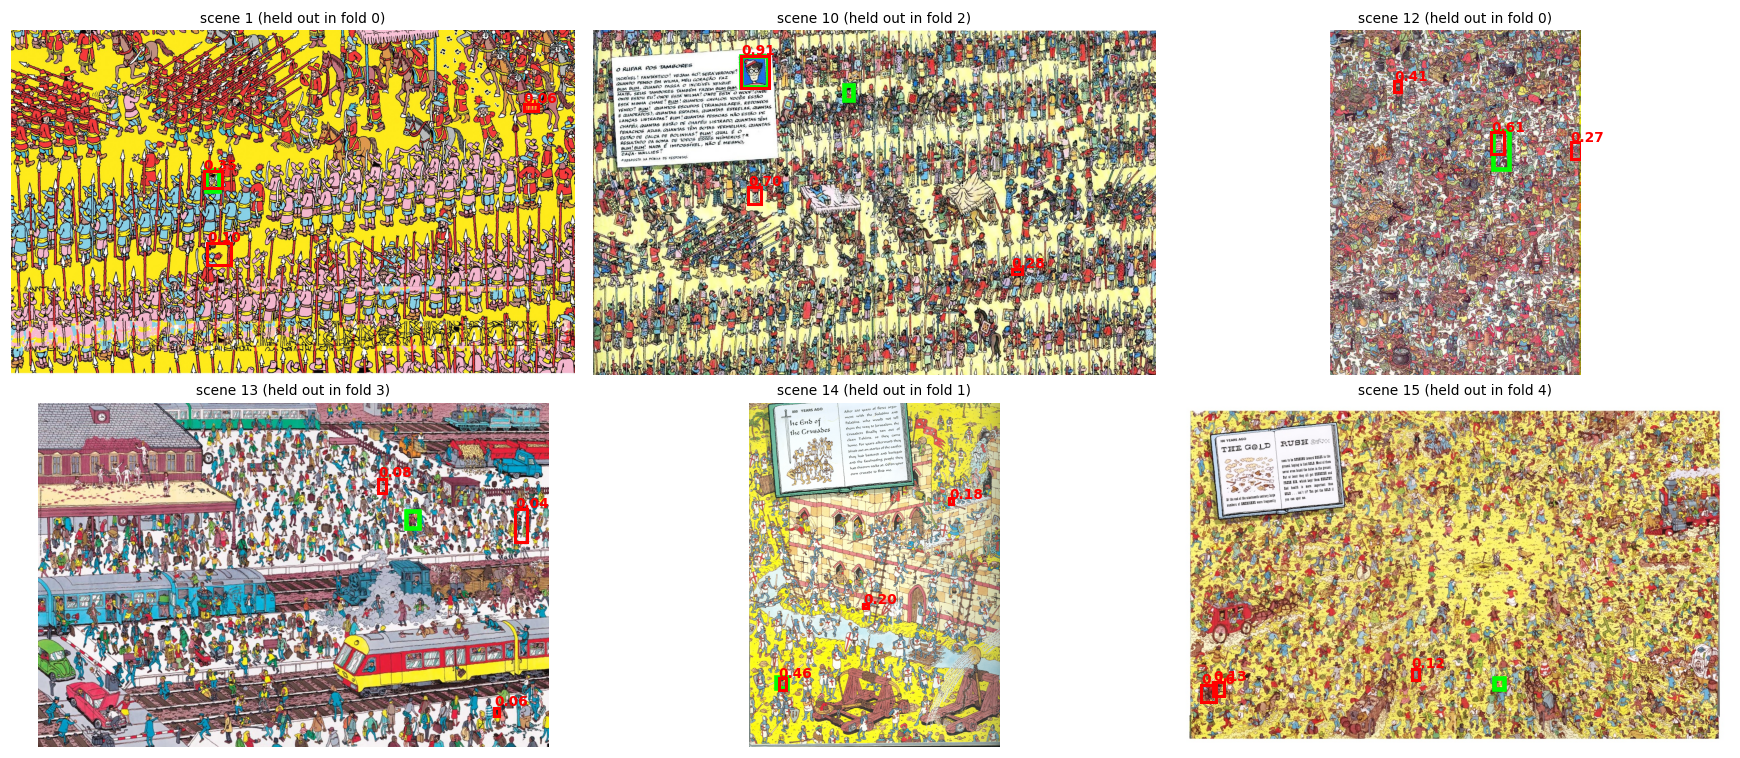

In [10]:
det_df = det_dfs["multi-scale"]
show = with_waldo.sort_values("scene_id").iloc[:6]
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for ax, (_, scene) in zip(axes.ravel(), show.iterrows()):
    ax.imshow(Image.open(scene["image_path"]))
    for (x1, y1, x2, y2) in scene["boxes"]:
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="lime", linewidth=3))
    for _, r in det_df[det_df["scene_id"] == scene["scene_id"]].head(3).iterrows():
        ax.add_patch(plt.Rectangle((r.x1, r.y1), r.x2 - r.x1, r.y2 - r.y1, fill=False, edgecolor="red", linewidth=2))
        ax.text(r.x1, r.y1 - 6, f"{r.score:.2f}", color="red", fontsize=9, weight="bold")
    ax.set_title(f"scene {scene['scene_id']} (held out in fold {scene['val_fold']})", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Save the final model

`models/yolo_tiled_detector.pt` is the **final model trained on all 19 scenes** — it has seen more data than any fold
model, so its performance on a *new* scene should be at least as good as the cross-validated numbers above, but that
is an expectation, not a measurement (there is no held-out scene left to check it on).

The demo scans at multiple scales and shows the **top few candidates above a low confidence floor (0.05)**, not just
boxes above the F1-optimal threshold. Reason: the demo answers "where should I look?", and the held-out numbers say
the top-3 boxes contain Waldo in 13 of 18 scenes (top-1: 10 of 18) while an F1-optimal cut-off (≈ 0.6) often shows
nothing at all. Both values are stored in `models/yolo_tiled_config.json`, and the demo lets you move the slider.

In [11]:
F1_OPTIMAL_CONF = float(sweep_dfs["multi-scale"].loc[sweep_dfs["multi-scale"]["f1"].idxmax(), "threshold"])
DEMO_CONF = 0.05  # show the top few candidates above a low floor; see the markdown above
shutil.copy(final_weights, MODELS_DIR / "yolo_tiled_detector.pt")
(MODELS_DIR / "yolo_tiled_config.json").write_text(
    json.dumps({"conf": DEMO_CONF, "f1_optimal_conf": F1_OPTIMAL_CONF, "tile": TILE, "overlap": OVERLAP,
                "scales": list(DEFAULT_SCALES)})
)
print(f"Saved final all-scenes model to {MODELS_DIR / 'yolo_tiled_detector.pt'} "
      f"(demo conf {DEMO_CONF}, pooled F1-optimal conf {F1_OPTIMAL_CONF})")

Saved final all-scenes model to D:\python_envs\wheres-wally\models\yolo_tiled_detector.pt (demo conf 0.05, pooled F1-optimal conf 0.6)


## Takeaways → what this motivates for notebook 06

- **The best detector so far, and the first that finds Waldo more often than not.** Held-out, threshold-free: Waldo
  is the detector's #1 box in 8 of 18 scenes with single-scale scanning and 10 of 18 with multi-scale, in its top-3
  in 10 / 13 of 18 (multi-scale: 72%), and in its top-10 in 10 / 14 of 18. At a low fixed threshold (0.05,
  multi-scale) it finds 15 of the 21 boxes, at the cost of 240 false boxes (~13 per scene).
- **With a properly held-out threshold the picture is more modest and noisier.** Leave-one-fold-out, single-scale:
  6 correct, 0 false, 15 missed (precision 1.00, recall 0.29). Multi-scale: 7 correct, 14 false, 14 missed
  (precision 0.33, recall 0.33). Multi-scale *ranks* better but scores worse here because the F1-optimal threshold
  is unstable with so few positives: for fold 4 it came out at 0.3 (chosen from the other four folds), which then
  produced 12 false boxes in two scenes, one of which has no annotated Waldo at all. Ranking (hit@k) is the more
  trustworthy readout here.
- **Correct labels mattered more than the model.** The same recipe trained on the misaligned boxes reached top-10 in
  4 of 18 scenes; on correct boxes, 10 of 18 (single-scale).
- **Caveats.** 21 boxes in 18 scenes is a small evaluation set; the multi-scale variant was chosen on these same
  scenes (see above), so treat it as somewhat optimistic; three annotations are Waldo *portraits on postcard
  stamps* rather than hidden figures, so "found Waldo" here includes them; and the final all-scenes model cannot be
  scored (nothing is held out). In scenes 2, 3 and 13 no box matching Waldo appears at confidence ≥ 0.01, and in
  scene 7 the first one is only at rank 36 — I have not analysed why.
- **Cost.** ~1.8 s per full scene single-scale and ~6 s multi-scale on this laptop CPU, versus roughly 4 s for the
  sliding-window CNN and well under 0.2 s for whole-scene YOLO.

Notebook 06 puts all three detectors side by side.